# Momepy roads — Berlin

This notebook uses momepy to calculate geometrical and topological features of the Berlin street network:
- **Street profile**: width, openness, width deviation (requires OSM buildings)
- **Betweenness centrality** (edge-based, metric, weighted by length)
- **Global closeness centrality** (node-based, weighted)
- **Local closeness centrality** (radius = 400 m)
- **Straightness centrality**

Input: `BER_noise_streets.gpkg` — the Berlin OSM drive streets with projected noise values created by `BER_OSM_roads_noise_class.ipynb`.

> **Note:** Betweenness and global closeness on ~70 k segments take significant time (potentially 30–90 min each).

## Import libraries

In [1]:
import os
import momepy as mm
import geopandas as gpd
import osmnx as ox
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

## Import streets segments

In [2]:
_layers_dir = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), 'layers')
edges = gpd.read_file(os.path.join(_layers_dir, 'BER_noise_streets.gpkg'))
print(edges.crs)  # CRS = Coordinate Reference System
print(edges.shape)
print(edges.columns.tolist())
print('Number of street segments:', len(edges))

EPSG:25833
(70890, 12)
['segment_id', 'highway', 'name', 'length', 'GES_DEN_mean', 'GES_N_mean', 'noise_day', 'noise_evening', 'noise_night', 'n_points', 'distance', 'geometry']
Number of street segments: 70890


In [3]:
place_name = 'Berlin, Germany'
tags = {'building': True}

print('Downloading buildings from OSM...')
try:
    buildings = ox.features_from_place(place_name, tags)
except AttributeError:
    buildings = ox.geometries_from_place(place_name, tags)

print(f'Downloaded {len(buildings)} buildings.')
buildings = buildings[buildings.geometry.type.isin(['Polygon', 'MultiPolygon'])]
buildings = buildings.to_crs(edges.crs)
display(buildings.head(3))

Downloaded 503022 buildings.


geometry addr:city  \
element  id                                                                  
relation 3197  POLYGON ((385399.157 5816830.057, 385403.657 5...       NaN   
         3212  POLYGON ((386524.588 5826152.311, 386525.029 5...    Berlin   
         3215  POLYGON ((382885.701 5819074.09, 382886.065 58...    Berlin   

              addr:housenumber addr:postcode      addr:street amenity  \
element  id                                                             
relation 3197              NaN           NaN              NaN     NaN   
         3212               67         13403  Kienhorststraße     NaN   
         3215             8-14         14057     Masurenallee     NaN   

              building name short_name  url  ... nudism branch:en check_in  \
element  id                                  ...                             
relation 3197   public  NaN        NaN  NaN  ...    NaN       NaN      NaN   
         3212   school  NaN        NaN  NaN  ...    NaN       NaN      NaN   
         3215   office  NaN        NaN  NaN  ...    NaN       NaN      NaN   

              dog:fee note:payment:cash source:access:password  \
element  id                                                      
relation 3197     NaN               NaN                    NaN   
         3212     NaN               NaN                    NaN   
         3215     NaN               NaN                    NaN   

              source:internet_access:password changing_table:location:notes  \
element  id                                                                   
relation 3197                             NaN                           NaN   
         3212                             NaN                           NaN   
         3215                             NaN                           NaN   

              was:content was:man_made  
element  id                             
relation 3197         NaN          NaN  
         3212         NaN          NaN  
         3215         NaN          NaN  

[3 rows x 1348 columns]

## Create Momepy street profile

In [4]:
profile = mm.street_profile(edges, buildings)
profile.head()

,width,openness,width_deviation
0,28.940821,0.728070,3.174008
1,43.648847,0.924419,1.857882
2,37.132640,0.797297,2.742866
3,50.000000,1.000000,NaN
4,49.244843,0.933333,0.615090


In [5]:
edges[profile.columns] = profile
edges[profile.columns].head()

,width,openness,width_deviation
0,28.940821,0.728070,3.174008
1,43.648847,0.924419,1.857882
2,37.132640,0.797297,2.742866
3,50.000000,1.000000,NaN
4,49.244843,0.933333,0.615090


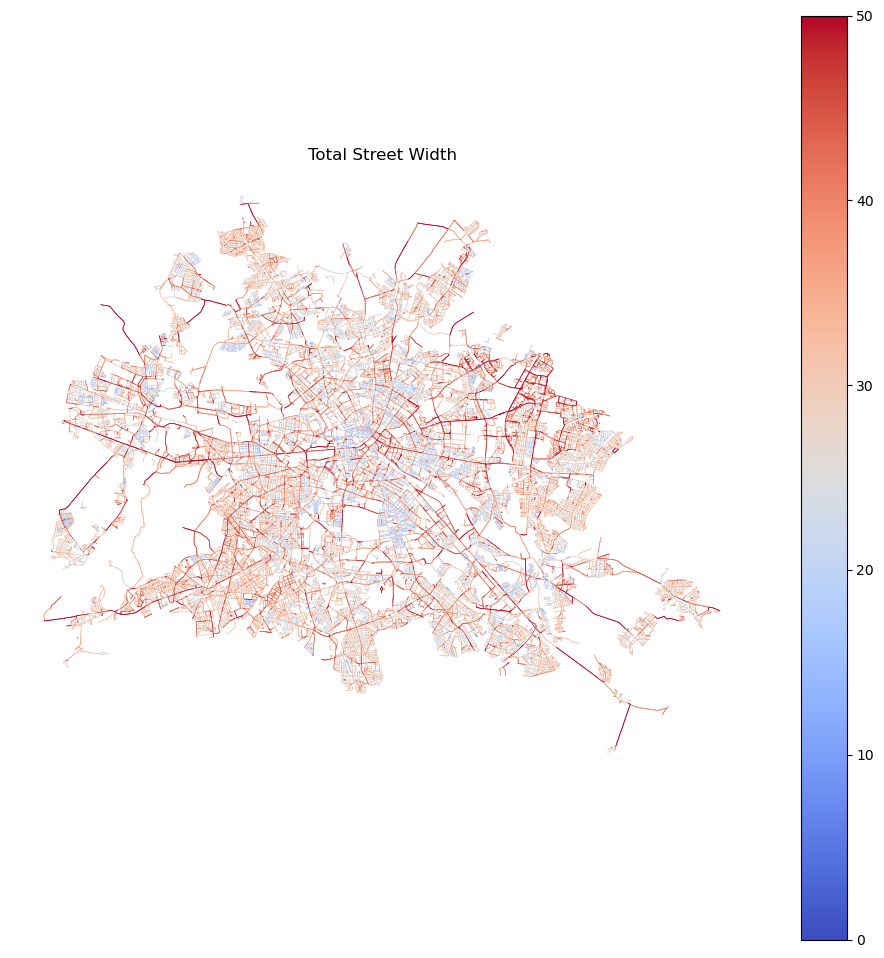

In [6]:
ax = edges.plot(cmap='coolwarm', column='width', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Total Street Width')
ax.set_axis_off()

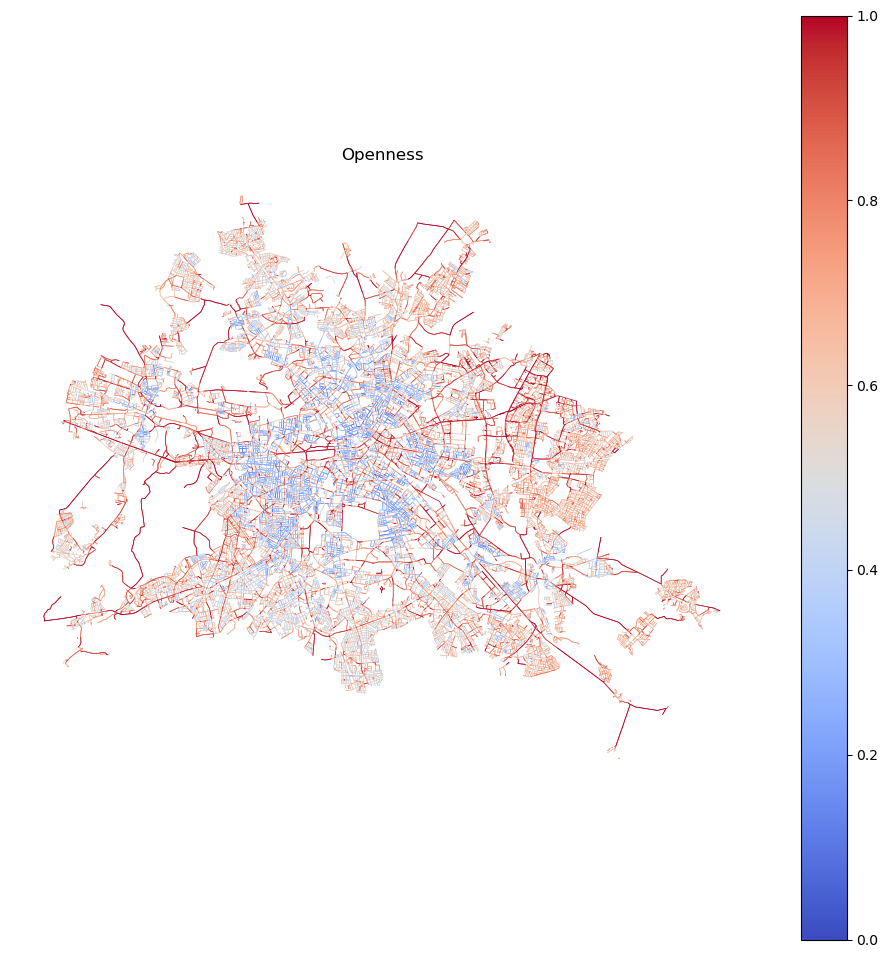

In [7]:
ax = edges.plot(cmap='coolwarm', column='openness', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Openness')
ax.set_axis_off()

# Centrality

## Betweenness Centrality

In [8]:
primal = mm.gdf_to_nx(edges, approach='primal')

Careful, takes long

In [ ]:
betweenness = mm.betweenness_centrality(
    primal, name='betweenness_metric_e', mode='edges', weight='mm_len'
)

In [ ]:
primal_gdf_betw = mm.nx_to_gdf(betweenness, points=False)
primal_gdf_betw.head()

In [ ]:
ax = primal_gdf_betw.plot(
    column='betweenness_metric_e',
    cmap='Spectral_r',
    scheme='quantiles',
    alpha=0.8,
    legend=True,
    figsize=(12, 12)
)
ax.set_axis_off()
ax.set_title('Betweenness Centrality (Edge Based)')

## Global Closeness Centrality

Careful, takes long

In [ ]:
closeness = mm.closeness_centrality(
    primal, name='closeness_global', weight='mm_len'
)

In [ ]:
nodes = mm.nx_to_gdf(closeness, lines=False)
nodes.head()
nodes.info()

In [ ]:
ax = nodes.plot(
    column='closeness_global',
    cmap='Spectral_r',
    scheme='quantiles',
    k=15,
    alpha=0.6,
    figsize=(12, 12),
    legend=True
)
ax.set_axis_off()
ax.set_title('Closeness Global (Node Based)')

In [ ]:
mm.mean_nodes(closeness, 'closeness_global')

In [ ]:
primal_gdf_clos = mm.nx_to_gdf(closeness, points=False)
primal_gdf_clos.head()

In [ ]:
ax = primal_gdf_clos.plot(
    column='closeness_global',
    cmap='Spectral_r',
    scheme='quantiles',
    k=15,
    alpha=0.6,
    figsize=(12, 12),
    legend=True
)
ax.set_axis_off()
_ = ax.set_title('Closeness Global Edge Mean')

## Local Closeness Centrality

In [ ]:
local_clos = mm.closeness_centrality(
    primal, radius=400, name='closeness400', distance='mm_len', weight='mm_len'
)

In [ ]:
nodes = mm.nx_to_gdf(local_clos, lines=False)
ax = nodes.plot(
    column='closeness400',
    cmap='Spectral_r',
    scheme='quantiles',
    k=15,
    alpha=0.6,
    figsize=(15, 15),
)
ax.set_axis_off()
_ = ax.set_title('closeness400')

In [ ]:
mm.mean_nodes(local_clos, 'closeness400')

In [ ]:
local_clos_gdf = mm.nx_to_gdf(local_clos, points=False)

ax = local_clos_gdf.plot(
    column='closeness400',
    cmap='Spectral_r',
    scheme='quantiles',
    k=15,
    alpha=0.6,
    figsize=(15, 15),
)
ax.set_axis_off()
_ = ax.set_title('closeness400')

## Straightness

In [ ]:
straighteness = mm.straightness_centrality(
    primal
)

In [ ]:
nodes = mm.nx_to_gdf(straighteness, lines=False)
ax = nodes.plot(
    column='straightness',
    cmap='Spectral_r',
    scheme='quantiles',
    k=15,
    alpha=0.6,
    figsize=(15, 15),
)
ax.set_axis_off()
_ = ax.set_title('straightness')

In [ ]:
mm.mean_nodes(straighteness, 'straightness')

In [ ]:
primal_gdf_straight = mm.nx_to_gdf(straighteness, points=False)
primal_gdf_straight.head()

In [ ]:
ax = primal_gdf_straight.plot(
    column='straightness',
    cmap='Spectral_r',
    scheme='quantiles',
    k=15,
    alpha=0.6,
    figsize=(12, 12),
)
ax.set_axis_off()
_ = ax.set_title('Straightness')

## Merge all centrality features

Combine betweenness, global closeness, local closeness and straightness into a single edge GeoDataFrame.

In [ ]:
# primal_gdf_straight already has width, openness, height from the street_profile step
# (momepy stores profile columns on the graph edges during gdf_to_nx / nx_to_gdf rounds)
primal_gdf = primal_gdf_straight.copy()

# Add betweenness
if 'segment_id' in primal_gdf_betw.columns:
    primal_gdf = primal_gdf.merge(
        primal_gdf_betw[['segment_id', 'betweenness_metric_e']],
        on='segment_id', how='left'
    )
else:
    primal_gdf['betweenness_metric_e'] = primal_gdf_betw['betweenness_metric_e'].values

# Add global closeness
if 'segment_id' in primal_gdf_clos.columns:
    primal_gdf = primal_gdf.merge(
        primal_gdf_clos[['segment_id', 'closeness_global']],
        on='segment_id', how='left'
    )
else:
    primal_gdf['closeness_global'] = primal_gdf_clos['closeness_global'].values

# Add local closeness
if 'segment_id' in local_clos_gdf.columns:
    primal_gdf = primal_gdf.merge(
        local_clos_gdf[['segment_id', 'closeness400']],
        on='segment_id', how='left'
    )
else:
    primal_gdf['closeness400'] = local_clos_gdf['closeness400'].values

print(primal_gdf.columns.tolist())
primal_gdf.head()

## Merge with noise dataset

In [ ]:
noise_dataset = pd.read_csv('data/osm_roads_noise_class.csv')

if 'segment_id' in primal_gdf.columns:
    merged = noise_dataset.merge(
        primal_gdf[['segment_id', 'closeness400']].rename(columns={'segment_id': 'road_id'}),
        on='road_id', how='left'
    )
else:
    merged = noise_dataset.copy()

merged.head()

## Create data frame

In [ ]:
# Safely retrieve columns — fall back to zeros if a metric is missing
def _col(gdf, col):
    return gdf[col] if col in gdf.columns else pd.Series(0.0, index=gdf.index)

dataset = pd.DataFrame({
    'road_id':         _col(primal_gdf, 'segment_id'),
    'width':           _col(primal_gdf, 'width'),
    'openness':        _col(primal_gdf, 'openness'),
    'height':          _col(primal_gdf, 'height'),
    'betw_centrality': _col(primal_gdf, 'betweenness_metric_e'),
    'clos_centrality': _col(primal_gdf, 'closeness_global'),
    'straightness':    _col(primal_gdf, 'straightness'),
    'closeness400':    _col(primal_gdf, 'closeness400'),
}).fillna(0)

dataset.head()

## Export dataset to CSV

In [ ]:
output_dir = 'data'
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, 'momepy_roads_features.csv'), index=False)
print('Exported momepy_roads_features.csv')